# Cancellation Risk Analysis

Cancellation driver exploration across lead time, channel, deposit behavior, seasonality, and customer type.

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
bookings = pd.read_csv(ROOT / 'data/processed/hotel_bookings_cleaned.csv')
risk = pd.read_csv(ROOT / 'outputs/tables/cancellation_risk_matrix.csv')
risk.head(10)

,hotel,market_segment,distribution_channel,deposit_type,lead_time_band,bookings,cancellations,cancellation_rate,lost_revenue_estimate,average_lead_time,previous_cancellations,special_request_rate,risk_priority_score
0,City Hotel,Groups,TA/TO,Non Refund,6-12 months,2911,2911,1.000000,626676.50,287.741326,0.478186,0.0,74.15
1,City Hotel,Groups,TA/TO,Non Refund,12+ months,1466,1466,1.000000,203016.19,460.796726,0.103683,0.0,73.17
2,City Hotel,Offline TA/TO,TA/TO,Non Refund,6-12 months,1967,1966,0.999492,532040.60,268.228775,0.260803,0.0,72.01
3,City Hotel,Offline TA/TO,TA/TO,Non Refund,12+ months,282,282,1.000000,48700.00,428.535461,0.141844,0.0,69.71
4,Resort Hotel,Groups,TA/TO,Non Refund,12+ months,97,97,1.000000,27039.00,414.309278,0.000000,0.0,68.91
5,City Hotel,Groups,TA/TO,Non Refund,3-6 months,1699,1699,1.000000,527676.14,138.452619,0.132431,0.0,67.75
6,City Hotel,Offline TA/TO,TA/TO,Non Refund,3-6 months,1579,1579,1.000000,473126.80,134.112096,0.214693,0.0,66.75
7,Resort Hotel,Groups,TA/TO,Non Refund,6-12 months,369,368,0.997290,95993.85,245.794038,0.197832,0.0,64.35
8,Resort Hotel,Groups,Corporate,Non Refund,6-12 months,131,131,1.000000,23076.00,252.343511,6.969466,0.0,63.57
9,Resort Hotel,Offline TA/TO,TA/TO,Non Refund,6-12 months,121,120,0.991736,29931.83,250.033058,8.909091,0.0,63.15


In [2]:
drivers = (bookings.groupby('lead_time_band')
    .agg(bookings=('booking_id', 'count'),
         cancellation_rate=('is_canceled', 'mean'),
         lost_revenue=('lost_revenue_estimate', 'sum'))
    .reset_index())
drivers

,lead_time_band,bookings,cancellation_rate,lost_revenue
0,1-3 months,29529,0.377290,4311567.27
1,1-4 weeks,18945,0.278860,2039854.24
2,12+ months,3147,0.676517,353385.77
3,3-6 months,26420,0.447350,5121135.54
4,6-12 months,21534,0.554565,4415532.03
5,Same week,19635,0.096002,449229.89


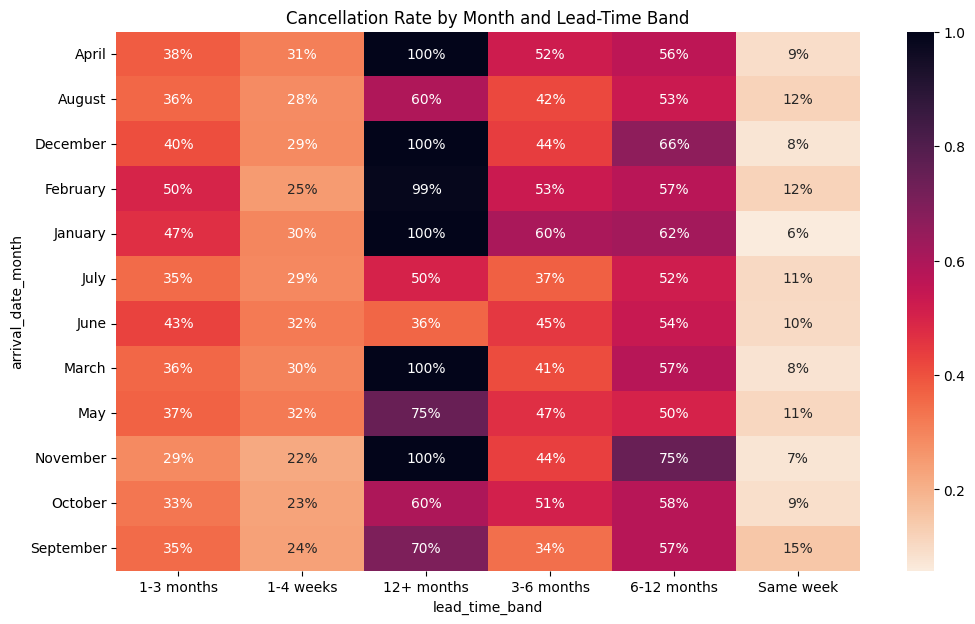

In [3]:
pivot = bookings.pivot_table(index='arrival_date_month', columns='lead_time_band',
                               values='is_canceled', aggfunc='mean')
plt.figure(figsize=(12, 7))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='rocket_r')
plt.title('Cancellation Rate by Month and Lead-Time Band')
plt.show()